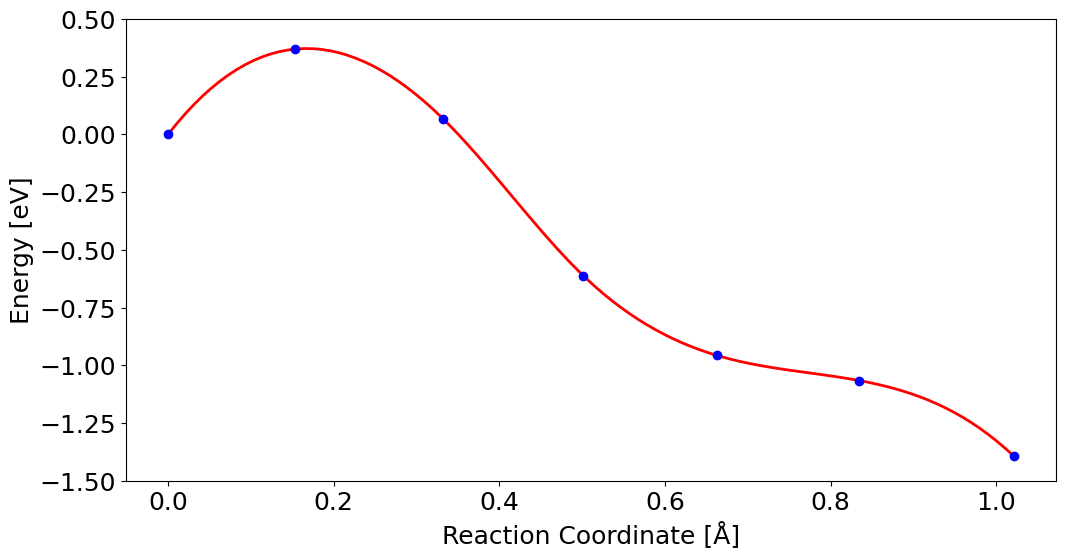

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg
from scipy.interpolate import make_interp_spline


# Sample reaction coordinate and energy data
reaction_coord = np.array([0.      , 0.153407, 0.331679, 0.50122 , 0.662986, 0.834506, 1.021047])
energy = np.array([0.0, 0.3690000000000282, 0.06830000000006747, -0.6115999999999349, -0.9574999999999636,
 -1.0658999999999423, -1.3923999999999432])

spline = make_interp_spline(reaction_coord, energy, k=3)  # k=3 for cubic spline
smooth_x = np.linspace(reaction_coord.min(), reaction_coord.max(), 100)
smooth_y = spline(smooth_x)

# Load example images (Replace with actual image file paths)
image_paths = ["image0.png", "image1.png", "image2.png", "image3.png", "image4.png", "image5.png", "image6.png"]

# Add inset images symmetrically
image_size = 1  # Adjust to control image size
for i, (x, y, img_path) in enumerate(zip(reaction_coord, energy, image_paths)):
    ax_inset = inset_axes(ax, width=image_size, height=image_size, bbox_to_anchor=(x, y + 0.2),
                           bbox_transform=ax.transData, loc="center", borderpad=0)
    img = mpimg.imread(img_path)  # Load image
    ax_inset.imshow(img)
    ax_inset.axis("off")  # Hide axes in inset images

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot smooth reaction energy curve
ax.plot(smooth_x, smooth_y, 'r-', linewidth=2, label="Spline Fit")
ax.scatter(reaction_coord, energy, color='blue', zorder=3)  # Data points

# Labels and formatting
ax.set_xlabel("Reaction Coordinate [Å]", fontsize=18)
ax.set_ylabel("Energy [eV]", fontsize=18)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.set_ylim(-1.5, 0.5)
# ax.set_title("Reaction Energy Profile with Aligned Images")

plt.show()